In [1]:
from pathlib import Path

DATA_DIR = Path("../data/raw/aclImdb")

print(DATA_DIR.exists())

True


In [5]:
from pathlib import Path

DATA_DIR = Path("../data/raw/aclImdb")

print(DATA_DIR)
print(DATA_DIR.exists())

..\data\raw\aclImdb
True


In [6]:
import os

print(os.getcwd())

c:\Users\dr_ra\OneDrive\Desktop\IMDB-Sentiment-Research\notebooks


In [7]:
DATA_DIR = Path("data/raw/aclImdb")

In [8]:
from pathlib import Path

for item in Path(".").iterdir():
    print(item)

EDA.ipynb


In [9]:
from pathlib import Path

DATA_DIR = Path("data/raw/aclImdb")

train_pos = list((DATA_DIR / "train" / "pos").glob("*.txt"))
train_neg = list((DATA_DIR / "train" / "neg").glob("*.txt"))

print("Positive reviews:", len(train_pos))
print("Negative reviews:", len(train_neg))

Positive reviews: 0
Negative reviews: 0


In [10]:
print(os.getcwd())
print(DATA_DIR.exists())

c:\Users\dr_ra\OneDrive\Desktop\IMDB-Sentiment-Research\notebooks
False


In [12]:
import os

print(os.getcwd())

c:\Users\dr_ra\OneDrive\Desktop\IMDB-Sentiment-Research\notebooks


In [13]:
from pathlib import Path

DATA_DIR = Path("../data/raw/aclImdb")
print(DATA_DIR.exists())

True


In [14]:
import os

print(os.getcwd())

c:\Users\dr_ra\OneDrive\Desktop\IMDB-Sentiment-Research\notebooks


In [15]:
from pathlib import Path

raw_path = Path("../data/raw")

for item in raw_path.iterdir():
    print(item)

..\data\raw\aclImdb


In [16]:
from pathlib import Path

print(list(Path("../data/raw").glob("*")))

[WindowsPath('../data/raw/aclImdb')]


In [17]:
from pathlib import Path

DATA_DIR = Path("../data/raw/aclImdb")

print(DATA_DIR.exists())

train_pos = list((DATA_DIR / "train" / "pos").glob("*.txt"))
train_neg = list((DATA_DIR / "train" / "neg").glob("*.txt"))

print("Positive reviews:", len(train_pos))
print("Negative reviews:", len(train_neg))

True
Positive reviews: 12500
Negative reviews: 12500


In [18]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data/raw/aclImdb")

In [19]:
def load_reviews(folder, label):
    reviews = []

    for file in folder.iterdir():
        with open(file, encoding="utf-8") as f:
            reviews.append({
                "review": f.read(),
                "label": label
            })

    return reviews

In [20]:
pos_reviews = load_reviews(
    DATA_DIR / "train" / "pos",
    1
)

neg_reviews = load_reviews(
    DATA_DIR / "train" / "neg",
    0
)

In [22]:
df = pd.DataFrame(
    pos_reviews + neg_reviews
)

df.head()

,review,label
0,Bromwell High is a cartoon comedy. It ran at t...,1
1,Homelessness (or Houselessness as George Carli...,1
2,Brilliant over-acting by Lesley Ann Warren. Be...,1
3,This is easily the most underrated film inn th...,1
4,This is not the typical Mel Brooks film. It wa...,1


In [23]:
print(df.shape)

(25000, 2)


In [24]:
df["label"].value_counts()

label
1    12500
0    12500
Name: count, dtype: int64

In [25]:
df["review_length"] = df["review"].apply(len)

df.head()

,review,label,review_length
0,Bromwell High is a cartoon comedy. It ran at t...,1,806
1,Homelessness (or Houselessness as George Carli...,1,2366
2,Brilliant over-acting by Lesley Ann Warren. Be...,1,841
3,This is easily the most underrated film inn th...,1,663
4,This is not the typical Mel Brooks film. It wa...,1,647


In [26]:
df["review_length"].describe()

count    25000.00000
mean      1325.06964
std       1003.13367
min         52.00000
25%        702.00000
50%        979.00000
75%       1614.00000
max      13704.00000
Name: review_length, dtype: float64

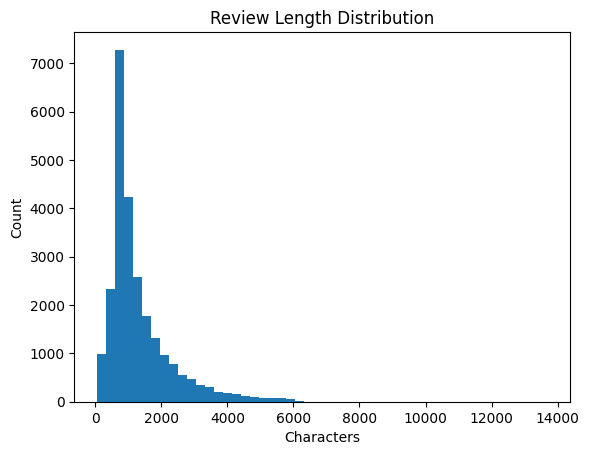

In [27]:
import matplotlib.pyplot as plt

plt.hist(
    df["review_length"],
    bins=50
)

plt.title("Review Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Count")

plt.show()

In [28]:
print(df.shape)

(25000, 3)


In [29]:
print(df.columns)

Index(['review', 'label', 'review_length'], dtype='str')


In [30]:
df["label"].value_counts()

label
1    12500
0    12500
Name: count, dtype: int64

In [31]:
df["review_length"].describe()

count    25000.00000
mean      1325.06964
std       1003.13367
min         52.00000
25%        702.00000
50%        979.00000
75%       1614.00000
max      13704.00000
Name: review_length, dtype: float64

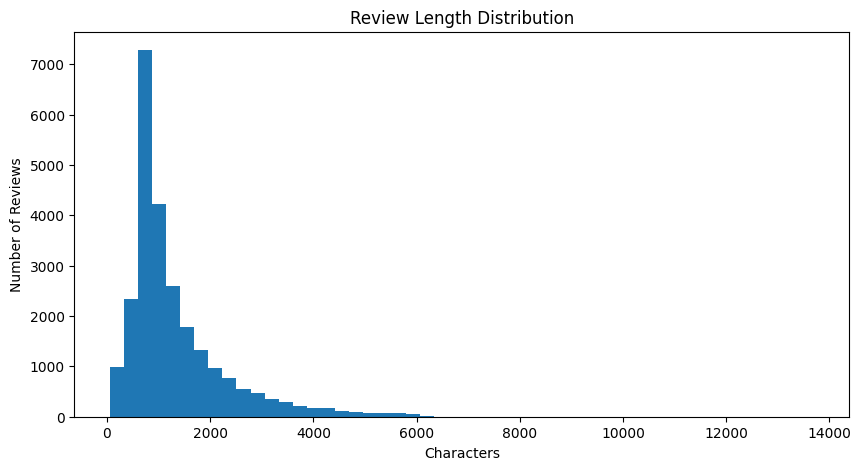

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    df["review_length"],
    bins=50
)

plt.title("Review Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Number of Reviews")

plt.show()

In [33]:
df["label"].value_counts()

label
1    12500
0    12500
Name: count, dtype: int64

In [34]:
df["review_length"].describe()

count    25000.00000
mean      1325.06964
std       1003.13367
min         52.00000
25%        702.00000
50%        979.00000
75%       1614.00000
max      13704.00000
Name: review_length, dtype: float64

In [35]:
df.sample(3)

,review,label,review_length
11922,"Xiao Chen Zhi Chun is a great movie, not only ...",1,363
7692,"This time around, Blackadder is no longer roya...",1,2404
13932,This movie was one of the worst I've ever seen...,0,918


In [36]:
df["sentiment"] = df["label"].map({
    0: "Negative",
    1: "Positive"
})

In [37]:
df[["sentiment"]].head()

,sentiment
0,Positive
1,Positive
2,Positive
3,Positive
4,Positive


In [38]:
print(
    df[df["label"] == 1]
    .iloc[0]["review"][:1000]
)

Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High's satire is much closer to reality than is "Teachers". The scramble to survive financially, the insightful students who can see right through their pathetic teachers' pomp, the pettiness of the whole situation, all remind me of the schools I knew and their students. When I saw the episode in which a student repeatedly tried to burn down the school, I immediately recalled ......... at .......... High. A classic line: INSPECTOR: I'm here to sack one of your teachers. STUDENT: Welcome to Bromwell High. I expect that many adults of my age think that Bromwell High is far fetched. What a pity that it isn't!


In [39]:


print(
    df[df["label"] == 0]
    .iloc[0]["review"][:1000]
)

Story of a man who has unnatural feelings for a pig. Starts out with a opening scene that is a terrific example of absurd comedy. A formal orchestra audience is turned into an insane, violent mob by the crazy chantings of it's singers. Unfortunately it stays absurd the WHOLE time with no general narrative eventually making it just too off putting. Even those from the era should be turned off. The cryptic dialogue would make Shakespeare seem easy to a third grader. On a technical level it's better than you might think with some good cinematography by future great Vilmos Zsigmond. Future stars Sally Kirkland and Frederic Forrest can be seen briefly.


In [41]:
df.to_csv(
    "../data/processed/train_reviews.csv",
    index=False
)

OSError: Cannot save file into a non-existent directory: '..\data\processed'

In [42]:
from pathlib import Path

print("Current directory:", Path.cwd())
print("Processed exists:", Path("../data/processed").exists())
print("Processed absolute path:", Path("../data/processed").resolve())

Current directory: c:\Users\dr_ra\OneDrive\Desktop\IMDB-Sentiment-Research\notebooks
Processed exists: False
Processed absolute path: C:\Users\dr_ra\OneDrive\Desktop\IMDB-Sentiment-Research\data\processed


In [43]:
from pathlib import Path

Path("../data/processed").mkdir(
    parents=True,
    exist_ok=True
)

print("Folder created/verified")

Folder created/verified


In [44]:
df.to_csv("../data/processed/train_reviews.csv", index=False)
print("Saved successfully")

Saved successfully


#Day 3 — Text Cleaning & NLP Preparation

In [46]:
import pandas as pd

df = pd.read_csv("../data/processed/train_reviews.csv")

print(df.shape)
df.head()

(25000, 4)


,review,label,review_length,sentiment
0,Bromwell High is a cartoon comedy. It ran at t...,1,806,Positive
1,Homelessness (or Houselessness as George Carli...,1,2366,Positive
2,Brilliant over-acting by Lesley Ann Warren. Be...,1,841,Positive
3,This is easily the most underrated film inn th...,1,663,Positive
4,This is not the typical Mel Brooks film. It wa...,1,647,Positive


In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   review         25000 non-null  str  
 1   label          25000 non-null  int64
 2   review_length  25000 non-null  int64
 3   sentiment      25000 non-null  str  
dtypes: int64(2), str(2)
memory usage: 32.6 MB


In [48]:
print(df.columns)

Index(['review', 'label', 'review_length', 'sentiment'], dtype='str')


In [49]:
print(df["review"].iloc[0])

Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High's satire is much closer to reality than is "Teachers". The scramble to survive financially, the insightful students who can see right through their pathetic teachers' pomp, the pettiness of the whole situation, all remind me of the schools I knew and their students. When I saw the episode in which a student repeatedly tried to burn down the school, I immediately recalled ......... at .......... High. A classic line: INSPECTOR: I'm here to sack one of your teachers. STUDENT: Welcome to Bromwell High. I expect that many adults of my age think that Bromwell High is far fetched. What a pity that it isn't!


In [52]:
df["review"].str.contains("<br").sum()

np.int64(14665)

In [53]:
import re

def clean_text(text):
    
    # remove html tags
    text = re.sub(r"<.*?>", " ", text)
    
    # remove extra spaces
    text = re.sub(r"\s+", " ", text)
    
    return text.strip()

In [54]:
sample = df["review"].iloc[0]

print("ORIGINAL:")
print(sample[:500])

print("\n" + "="*80 + "\n")

print("CLEANED:")
print(clean_text(sample)[:500])

ORIGINAL:
Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High's satire is much closer to reality than is "Teachers". The scramble to survive financially, the insightful students who can see right through their pathetic teachers' pomp, the pettiness of the whole situation, all remind me of the schools I knew and their students. When I saw the episode in which a s


CLEANED:
Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High's satire is much closer to reality than is "Teachers". The scramble to survive financially, the insightful students who can see right through their pathetic teachers' pomp, the pettiness of the whole situation, all remind me of the schools I knew and their students. When I saw th

In [55]:
df["clean_review"] = df["review"].apply(clean_text)

In [56]:
df.head()

,review,label,review_length,sentiment,clean_review
0,Bromwell High is a cartoon comedy. It ran at t...,1,806,Positive,Bromwell High is a cartoon comedy. It ran at t...
1,Homelessness (or Houselessness as George Carli...,1,2366,Positive,Homelessness (or Houselessness as George Carli...
2,Brilliant over-acting by Lesley Ann Warren. Be...,1,841,Positive,Brilliant over-acting by Lesley Ann Warren. Be...
3,This is easily the most underrated film inn th...,1,663,Positive,This is easily the most underrated film inn th...
4,This is not the typical Mel Brooks film. It wa...,1,647,Positive,This is not the typical Mel Brooks film. It wa...


In [57]:
df["clean_length"] = df["clean_review"].apply(len)

df[["review_length", "clean_length"]].head()

,review_length,clean_length
0,806,806
1,2366,2322
2,841,841
3,663,663
4,647,647


In [58]:
print(
    "Average Original Length:",
    df["review_length"].mean()
)

print(
    "Average Clean Length:",
    df["clean_length"].mean()
)

Average Original Length: 1325.06964
Average Clean Length: 1302.34384


In [59]:
df.to_csv(
    "../data/processed/train_reviews_clean.csv",
    index=False
)

print("Saved")

Saved


In [60]:
df["review"].str.contains("<br").sum()

np.int64(14665)

In [62]:
df.to_csv(
    "../data/processed/train_reviews_clean.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


In [63]:
import os

print(
    os.path.exists(
        "../data/processed/train_reviews_clean.csv"
    )
)

True


In [64]:
import os

print(
    os.path.exists(
        "../data/processed/train_reviews_clean.csv"
    )
)

True


In [65]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/train_reviews_clean.csv"
)

print(df.shape)

(25000, 6)


In [66]:
print(df.columns)

Index(['review', 'label', 'review_length', 'sentiment', 'clean_review',
       'clean_length'],
      dtype='str')


In [67]:
df.isnull().sum()

review           0
label            0
review_length    0
sentiment        0
clean_review     0
clean_length     0
dtype: int64

In [68]:
X = df["clean_review"]

y = df["label"]

In [1]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/train_reviews_clean.csv"
)

print(df.shape)

(25000, 6)


In [2]:
print(df.columns)

Index(['review', 'label', 'review_length', 'sentiment', 'clean_review',
       'clean_length'],
      dtype='str')


In [3]:
df.isnull().sum()

review           0
label            0
review_length    0
sentiment        0
clean_review     0
clean_length     0
dtype: int64

In [4]:
X = df["clean_review"]

y = df["label"]

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
print(X_train.shape)
print(X_test.shape)

(20000,)
(5000,)


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [9]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

In [12]:

X_train_tfidf = tfidf.fit_transform(
    X_train
)

X_test_tfidf = tfidf.transform(
    X_test
)

In [13]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(20000, 5000)
(5000, 5000)


In [14]:
print(
    list(
        tfidf.vocabulary_.keys()
    )[:20]
)

['reviews', 've', 'read', 'reveals', 'people', 'tend', 'like', 'better', 'feel', 'exactly', 'opposite', 'played', 'bit', 'trying', 'different', 'ways', 'showing', 'che', 'personality', 'types']


In [15]:
import joblib

In [16]:
joblib.dump(
    tfidf,
    "../models/tfidf_vectorizer.pkl"
)

['../models/tfidf_vectorizer.pkl']

In [17]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(20000, 5000)
(5000, 5000)


In [18]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [19]:
df = pd.read_csv(
    "../data/processed/train_reviews_clean.csv"
)

print(df.shape)

(25000, 6)


In [20]:
X = df["clean_review"]

y = df["label"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [23]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(
    X_train_tfidf,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [24]:
y_pred = model.predict(
    X_test_tfidf
)

In [28]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

print("Accuracy:", accuracy)

Accuracy: 0.8724
Accuracy: 0.8724


In [26]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.88      0.86      0.87      2500
           1       0.86      0.89      0.87      2500

    accuracy                           0.87      5000
   macro avg       0.87      0.87      0.87      5000
weighted avg       0.87      0.87      0.87      5000



In [27]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[2146  354]
 [ 284 2216]]


In [29]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.88      0.86      0.87      2500
           1       0.86      0.89      0.87      2500

    accuracy                           0.87      5000
   macro avg       0.87      0.87      0.87      5000
weighted avg       0.87      0.87      0.87      5000



In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.86      0.87      2500
           1       0.86      0.89      0.87      2500

    accuracy                           0.87      5000
   macro avg       0.87      0.87      0.87      5000
weighted avg       0.87      0.87      0.87      5000



In [31]:
print(confusion_matrix(y_test, y_pred))

[[2146  354]
 [ 284 2216]]


In [32]:
results = pd.DataFrame({
    "review": X_test,
    "actual": y_test,
    "predicted": y_pred
})

results.head()

,review,actual,predicted
3126,"Chloe is mysteriously saved from Dr. Caselli, ...",1,1
6278,The star of this film is the screenplay. Atten...,1,1
21427,"In the questionable comedy vein of Mel Brooks,...",0,0
16498,There was a great film to be made about Steve ...,0,0
2787,I just saw the movie on tv. I really enjoyed i...,1,1


In [33]:
false_positives = results[
    (results["actual"] == 0) &
    (results["predicted"] == 1)
]

print(len(false_positives))

354


In [34]:
false_negatives = results[
    (results["actual"] == 1) &
    (results["predicted"] == 0)
]

print(len(false_negatives))

284


In [35]:
import pandas as pd

results = pd.DataFrame({
    "review": X_test,
    "actual": y_test,
    "predicted": y_pred
})

results.head()

,review,actual,predicted
3126,"Chloe is mysteriously saved from Dr. Caselli, ...",1,1
6278,The star of this film is the screenplay. Atten...,1,1
21427,"In the questionable comedy vein of Mel Brooks,...",0,0
16498,There was a great film to be made about Steve ...,0,0
2787,I just saw the movie on tv. I really enjoyed i...,1,1


In [36]:
false_positives = results[
    (results["actual"] == 0) &
    (results["predicted"] == 1)
]

print("False Positives:", len(false_positives))

False Positives: 354


In [37]:
false_negatives = results[
    (results["actual"] == 1) &
    (results["predicted"] == 0)
]

print("False Negatives:", len(false_negatives))

False Negatives: 284


In [43]:
print(false_positives.iloc[0]["review"])

Just Cause is one of those films that at first makes you wonder quite why it was so heavily slated when it came out - nothing special but competent enough and with an excellent supporting performance from Ed Harris. Then you hit the last third and everything starts to get increasingly silly until you've got a killer with a flashlight strapped to his forehead threatening to fillet Sean Connery's wife (a typically mannered and unconvincing Kate Capshaw) and kid (a very young Scarlet Johannsen) in an alligator skinner's shack. The kind of movie that's probably best seen on a plane, and even then only once.


Why would the model think this is positive ?

In [42]:
print(false_negatives.iloc[0]["review"])


Apparently Ruggero Deodato figured out, early on, that his story wouldn't work if he approached it too seriously, so he decided to camp it up. The result is a film that can be viewed as either a ludicrous sword-and-sorcery epic or as a very entertaining comedy! And I think I'll go the second way. The brief gore moments are well-done, the Paul Brothers openly mock the material (they even bark at each other in one scene!), and there is also a charming, spirited, good-natured performance by Eva La Rue, as the girl who tags along with the "boys". Plus, where else can you see the insides of a dragon lighted like a discotheque?? (***)


Why would the model think this is negative ?

In [44]:
for i in range(10):
    print(false_positives.iloc[i]["review"][:1000])
    print("-"*80)

Just Cause is one of those films that at first makes you wonder quite why it was so heavily slated when it came out - nothing special but competent enough and with an excellent supporting performance from Ed Harris. Then you hit the last third and everything starts to get increasingly silly until you've got a killer with a flashlight strapped to his forehead threatening to fillet Sean Connery's wife (a typically mannered and unconvincing Kate Capshaw) and kid (a very young Scarlet Johannsen) in an alligator skinner's shack. The kind of movie that's probably best seen on a plane, and even then only once.
--------------------------------------------------------------------------------
We know that firefighters and rescue workers are heroes: an idée reçue few would challenge. Friends and family of these and others who perished in the attacks on the World Trade Center might well be moved by this vapid play turned film. A sweet, earnest, though tongue-tied fireman recalls what he can of los

In [45]:
for i in range(10):
    print(false_negatives.iloc[i]["review"][:1000])
    print("-"*80)

Apparently Ruggero Deodato figured out, early on, that his story wouldn't work if he approached it too seriously, so he decided to camp it up. The result is a film that can be viewed as either a ludicrous sword-and-sorcery epic or as a very entertaining comedy! And I think I'll go the second way. The brief gore moments are well-done, the Paul Brothers openly mock the material (they even bark at each other in one scene!), and there is also a charming, spirited, good-natured performance by Eva La Rue, as the girl who tags along with the "boys". Plus, where else can you see the insides of a dragon lighted like a discotheque?? (***)
--------------------------------------------------------------------------------
The daughter's words are poetry: "I can't go on another year. I got to get to a hotel room." "I lost my blue scarf in a sea of leaves." "The marble faun is moving in...he just gave us a washing machine. That's the deal." "I'm pulverized by this latest thing." "..raccoons and cats b

In [46]:
false_positives["length"] = (
    false_positives["review"].apply(len)
)

false_negatives["length"] = (
    false_negatives["review"].apply(len)
)

In [47]:
print(false_positives["length"].mean())
print(false_negatives["length"].mean())

1291.0282485875707
1329.7676056338028


In [48]:
print(df["review_length"].mean())

1325.06964


In [2]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [3]:
df = pd.read_csv(
    "../data/processed/train_reviews_clean.csv"
)

print(df.shape)

(25000, 6)


In [4]:
X = df["clean_review"]

y = df["label"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [7]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(
    X_train_tfidf,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [8]:
y_pred = model.predict(
    X_test_tfidf
)

In [9]:
print(
    accuracy_score(
        y_test,
        y_pred
    )
)

0.8724


In [10]:
results = pd.DataFrame({
    "review": X_test,
    "actual": y_test,
    "predicted": y_pred
})

print(results.shape)
results.head()

(5000, 3)


,review,actual,predicted
3126,"Chloe is mysteriously saved from Dr. Caselli, ...",1,1
6278,The star of this film is the screenplay. Atten...,1,1
21427,"In the questionable comedy vein of Mel Brooks,...",0,0
16498,There was a great film to be made about Steve ...,0,0
2787,I just saw the movie on tv. I really enjoyed i...,1,1


In [11]:
false_positives = results[
    (results["actual"] == 0) &
    (results["predicted"] == 1)
]

print("False Positives:", len(false_positives))

False Positives: 354


In [12]:
false_negatives = results[
    (results["actual"] == 1) &
    (results["predicted"] == 0)
]

print("False Negatives:", len(false_negatives))

False Negatives: 284


In [13]:
print(false_positives.iloc[0]["review"][:1500])

Just Cause is one of those films that at first makes you wonder quite why it was so heavily slated when it came out - nothing special but competent enough and with an excellent supporting performance from Ed Harris. Then you hit the last third and everything starts to get increasingly silly until you've got a killer with a flashlight strapped to his forehead threatening to fillet Sean Connery's wife (a typically mannered and unconvincing Kate Capshaw) and kid (a very young Scarlet Johannsen) in an alligator skinner's shack. The kind of movie that's probably best seen on a plane, and even then only once.


In [14]:
print(false_negatives.iloc[0]["review"][:1500])

Apparently Ruggero Deodato figured out, early on, that his story wouldn't work if he approached it too seriously, so he decided to camp it up. The result is a film that can be viewed as either a ludicrous sword-and-sorcery epic or as a very entertaining comedy! And I think I'll go the second way. The brief gore moments are well-done, the Paul Brothers openly mock the material (they even bark at each other in one scene!), and there is also a charming, spirited, good-natured performance by Eva La Rue, as the girl who tags along with the "boys". Plus, where else can you see the insides of a dragon lighted like a discotheque?? (***)


In [15]:
for i in range(10):
    print(f"\n--- FP {i+1} ---")
    print(false_positives.iloc[i]["review"][:1000])


--- FP 1 ---
Just Cause is one of those films that at first makes you wonder quite why it was so heavily slated when it came out - nothing special but competent enough and with an excellent supporting performance from Ed Harris. Then you hit the last third and everything starts to get increasingly silly until you've got a killer with a flashlight strapped to his forehead threatening to fillet Sean Connery's wife (a typically mannered and unconvincing Kate Capshaw) and kid (a very young Scarlet Johannsen) in an alligator skinner's shack. The kind of movie that's probably best seen on a plane, and even then only once.

--- FP 2 ---
We know that firefighters and rescue workers are heroes: an idée reçue few would challenge. Friends and family of these and others who perished in the attacks on the World Trade Center might well be moved by this vapid play turned film. A sweet, earnest, though tongue-tied fireman recalls what he can of lost colleagues to a benumbed journalist who converts hi

In [16]:
for i in range(10):
    print(f"\n--- FN {i+1} ---")
    print(false_negatives.iloc[i]["review"][:1000])


--- FN 1 ---
Apparently Ruggero Deodato figured out, early on, that his story wouldn't work if he approached it too seriously, so he decided to camp it up. The result is a film that can be viewed as either a ludicrous sword-and-sorcery epic or as a very entertaining comedy! And I think I'll go the second way. The brief gore moments are well-done, the Paul Brothers openly mock the material (they even bark at each other in one scene!), and there is also a charming, spirited, good-natured performance by Eva La Rue, as the girl who tags along with the "boys". Plus, where else can you see the insides of a dragon lighted like a discotheque?? (***)

--- FN 2 ---
The daughter's words are poetry: "I can't go on another year. I got to get to a hotel room." "I lost my blue scarf in a sea of leaves." "The marble faun is moving in...he just gave us a washing machine. That's the deal." "I'm pulverized by this latest thing." "..raccoons and cats become a little bit boring for too long a time." "..an

In [17]:
false_positives["length"] = false_positives["review"].apply(len)
false_negatives["length"] = false_negatives["review"].apply(len)

print("FP Avg Length:", false_positives["length"].mean())
print("FN Avg Length:", false_negatives["length"].mean())
print("Dataset Avg Length:", df["review_length"].mean())

FP Avg Length: 1291.0282485875707
FN Avg Length: 1329.7676056338028
Dataset Avg Length: 1325.06964


In [18]:
print(false_positives.iloc[0]["review"][:1000])
print(false_positives.iloc[1]["review"][:1000])
print(false_positives.iloc[2]["review"][:1000])

Just Cause is one of those films that at first makes you wonder quite why it was so heavily slated when it came out - nothing special but competent enough and with an excellent supporting performance from Ed Harris. Then you hit the last third and everything starts to get increasingly silly until you've got a killer with a flashlight strapped to his forehead threatening to fillet Sean Connery's wife (a typically mannered and unconvincing Kate Capshaw) and kid (a very young Scarlet Johannsen) in an alligator skinner's shack. The kind of movie that's probably best seen on a plane, and even then only once.
We know that firefighters and rescue workers are heroes: an idée reçue few would challenge. Friends and family of these and others who perished in the attacks on the World Trade Center might well be moved by this vapid play turned film. A sweet, earnest, though tongue-tied fireman recalls what he can of lost colleagues to a benumbed journalist who converts his fragments into a eulogy. T

In [19]:
false_positives.iloc[0]["review"][:1500]

"Just Cause is one of those films that at first makes you wonder quite why it was so heavily slated when it came out - nothing special but competent enough and with an excellent supporting performance from Ed Harris. Then you hit the last third and everything starts to get increasingly silly until you've got a killer with a flashlight strapped to his forehead threatening to fillet Sean Connery's wife (a typically mannered and unconvincing Kate Capshaw) and kid (a very young Scarlet Johannsen) in an alligator skinner's shack. The kind of movie that's probably best seen on a plane, and even then only once."

In [22]:
false_negatives.iloc[0]["review"][:1500]

'Apparently Ruggero Deodato figured out, early on, that his story wouldn\'t work if he approached it too seriously, so he decided to camp it up. The result is a film that can be viewed as either a ludicrous sword-and-sorcery epic or as a very entertaining comedy! And I think I\'ll go the second way. The brief gore moments are well-done, the Paul Brothers openly mock the material (they even bark at each other in one scene!), and there is also a charming, spirited, good-natured performance by Eva La Rue, as the girl who tags along with the "boys". Plus, where else can you see the insides of a dragon lighted like a discotheque?? (***)'

In [24]:
false_positives.iloc[1]["review"][:1500]


'We know that firefighters and rescue workers are heroes: an idée reçue few would challenge. Friends and family of these and others who perished in the attacks on the World Trade Center might well be moved by this vapid play turned film. A sweet, earnest, though tongue-tied fireman recalls what he can of lost colleagues to a benumbed journalist who converts his fragments into a eulogy. They ponder the results. He mumbles some more, she composes another eulogy, etc., etc. The dreadful events that provoked the need for several thousand eulogies is overwhelmingly sad, but this plodding insipid dramatization is distressingly boring.'

In [ ]:
false_negatives.iloc[1]["review"][:1500]

'The daughter\'s words are poetry: "I can\'t go on another year. I got to get to a hotel room." "I lost my blue scarf in a sea of leaves." "The marble faun is moving in...he just gave us a washing machine. That\'s the deal." "I\'m pulverized by this latest thing." "..raccoons and cats become a little bit boring for too long a time." "..any little rat\'s nest, mouse hole I\'d like better." And there is wisdom in the mother\'s words: "...yes the pleasure is all mine." "This little book will keep me straight, straight as a dye." "Always one must do everything correctly." "Where the hell did you come from?" "...bring me my little radio I\'ve got to have some professional music." "I\'m your mother. Remember me?" The mother/daughter relationship is drawn in this magnificent film. This is a Mother\'s day film.'

In [2]:
import sys
print(sys.executable)

c:\Users\dr_ra\anaconda3\envs\imdbsentiment\python.exe


In [4]:
import transformers
import torch

print(transformers.__version__)
print(torch.__version__)

5.9.0
2.12.0+cpu
